In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df=pd.read_csv("superstore.csv",encoding="latin1")
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


# Task: **01**

Skewness:  12.97275234181623
Mean:  229.85800083049833
Median:  54.489999999999995


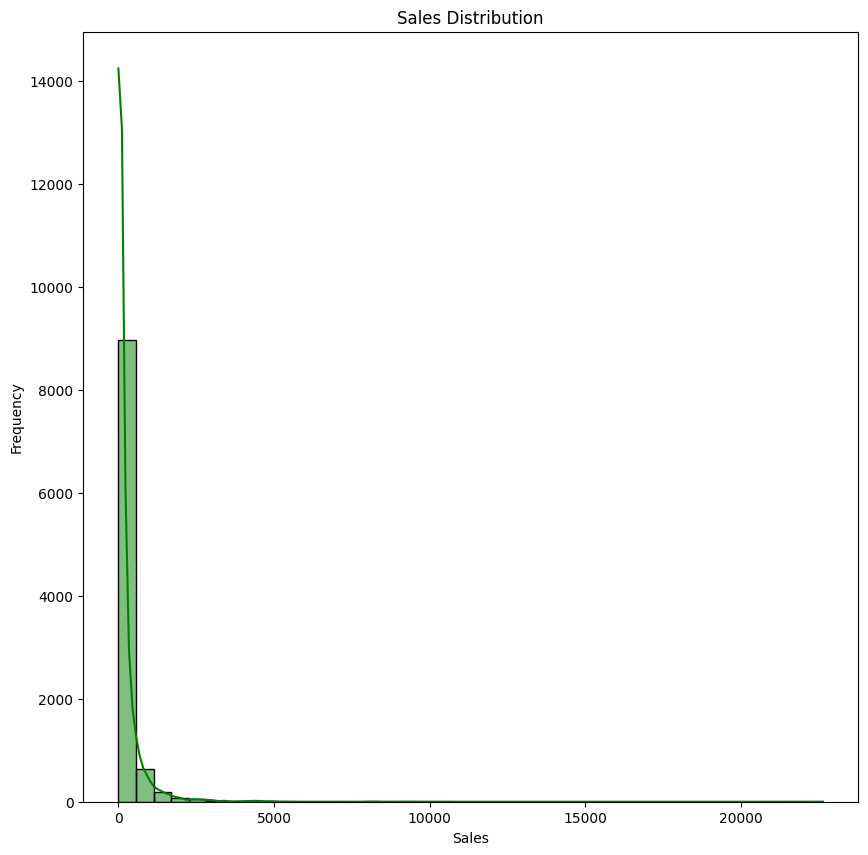

In [103]:
skewness=df["Sales"].skew()
mean=df["Sales"].mean()
median=df["Sales"].median()
print("Skewness: ",skewness)
print("Mean: ",mean)
print("Median: ",median)

plt.figure(figsize=(10,10))
sns.histplot(df["Sales"],kde=True,color="green",bins=40)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

The distribution is right skewed which is that mean is relatively high from that of median. And as we know that mean is affected by outkliers so it is clear that the difference in mean and median emphasize the presence of outliers and skewness of data as a whole.

# Task: **02**

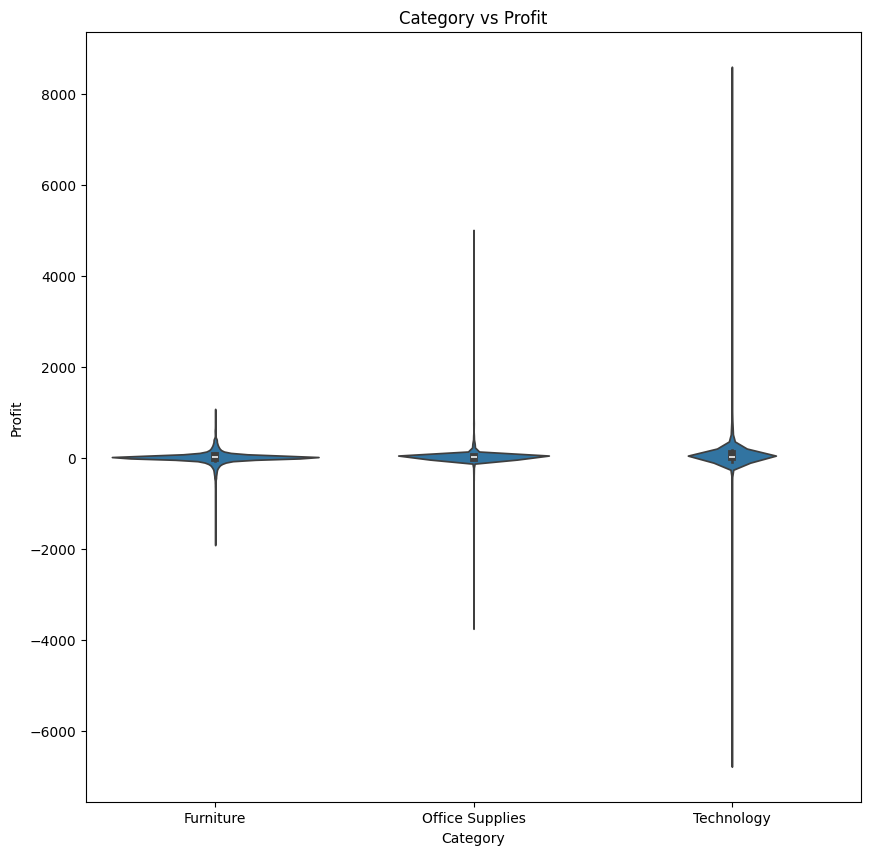

In [104]:
plt.figure(figsize=(10,10))
sns.violinplot(data=df, x='Category',y='Profit')
plt.title("Category vs Profit")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

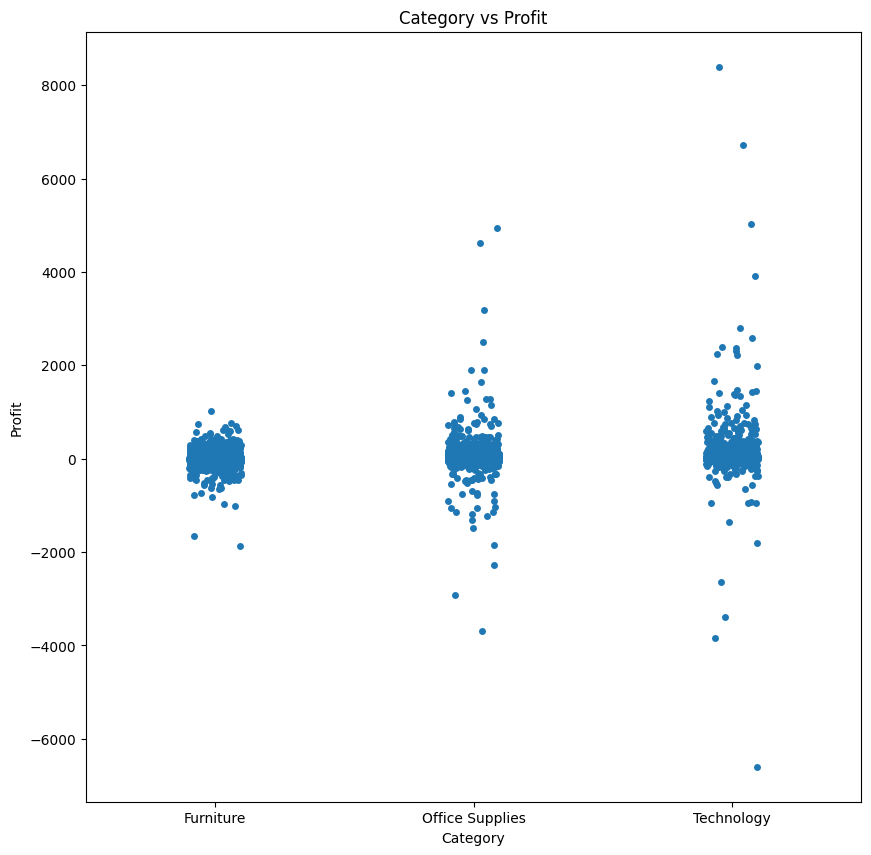

In [105]:
plt.figure(figsize=(10,10))
sns.stripplot(data=df, x='Category',y='Profit')
plt.title("Category vs Profit")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

The violin plot is better because it gives us the bimodal gap of the profit.

# Task: **03**

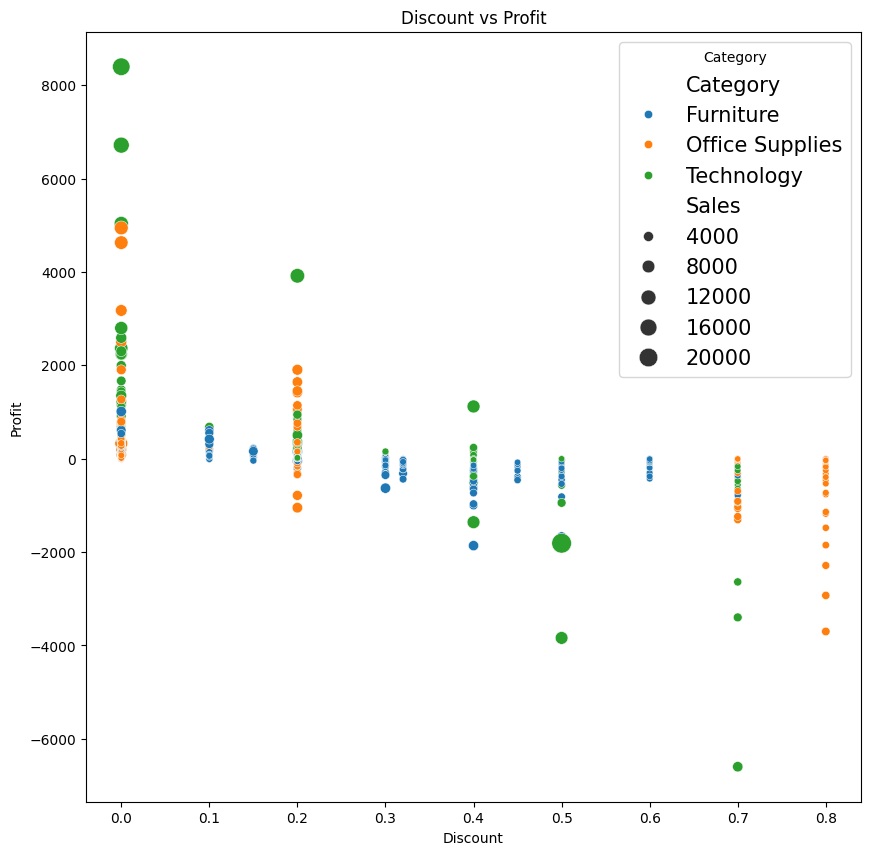

In [106]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df,x="Discount",y="Profit",hue="Category",size="Sales",sizes=(20,200))
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.legend(title="Category",loc="upper right",fontsize=15)
plt.show()

The pattern visible because of 4th variable is that when the discount is 0% and 50% we have the highest number of sales and for all other values of discount we have lower number of sales.

# Task: **04**

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000
             Sales  Quantity  Discount    Profit
Sales     1.000000  0.327426 -0.056969  0.518407
Quantity  0.327426  1.000000 -0.000878  0.234491
Discount -0.056969 -0.000878  1.000000 -0.543350
Profit    0.518407  0.234491 -0.543350  1.000000


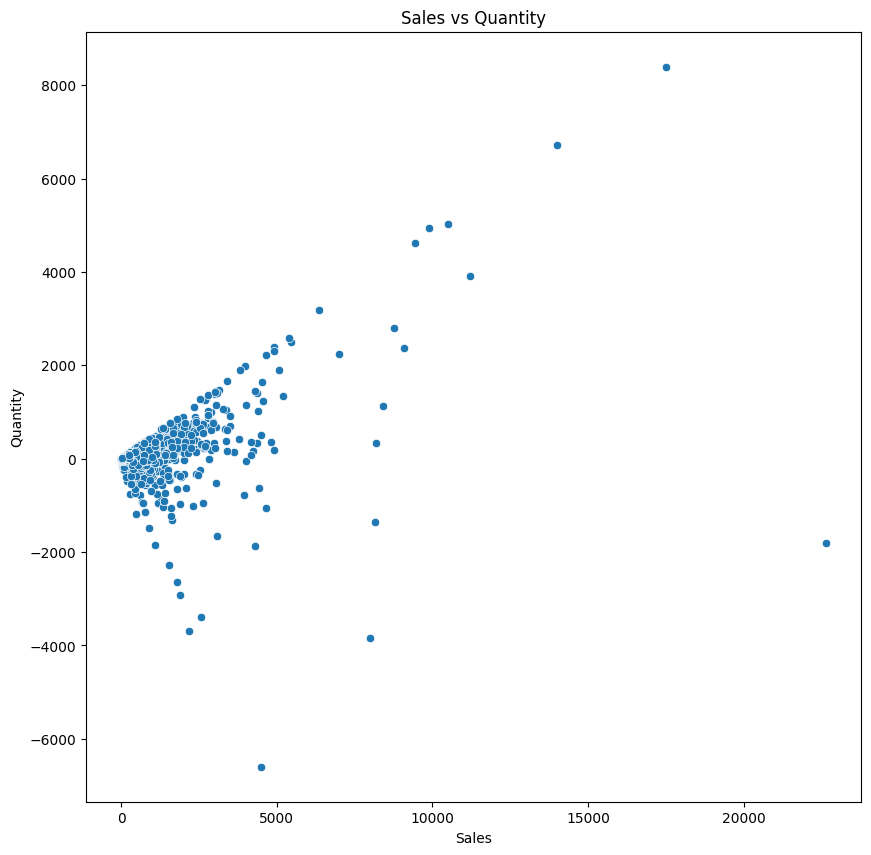

In [107]:
numericcolumns=df[["Sales","Quantity","Discount","Profit"]]
print(numericcolumns.corr(method="pearson"))
print(numericcolumns.corr(method="spearman"))

plt.figure(figsize=(10,10))
sns.scatterplot(data=df,x="Sales",y="Profit")
plt.title("Sales vs Quantity")
plt.xlabel("Sales")
plt.ylabel("Quantity")
plt.show()

In this the pearson signifies the linear relation despite the maximum and minimum relation whereas the spearman shows all correlation points.

# Task: **05**

Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


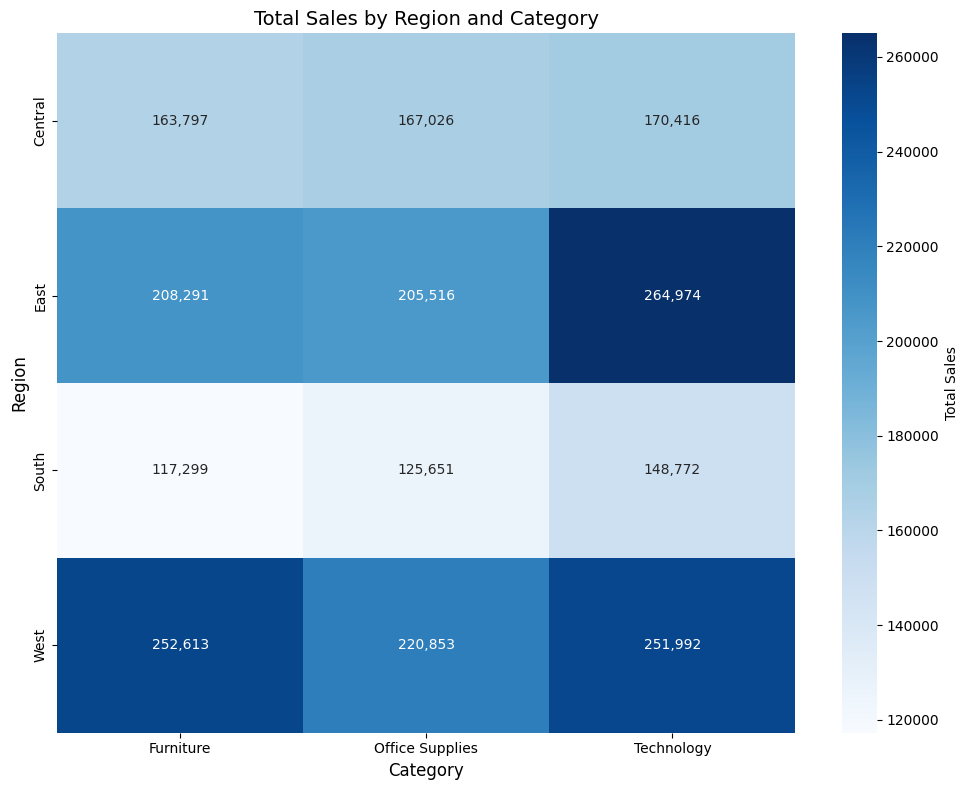

In [108]:
pivot_table=pd.pivot_table(df,index="Region",columns="Category",values="Sales",aggfunc="sum",margins=True)
print(pivot_table)
data=pivot_table.drop(index="All",columns="All",axis=0)
plt.figure(figsize=(10,8))
sns.heatmap(data,annot=True,fmt=",.0f",cmap="Blues",cbar_kws={"label":"Total Sales"},)
plt.title("Total Sales by Region and Category", fontsize=14)
plt.xlabel("Category",fontsize=12)
plt.ylabel("Region",fontsize=12)
plt.tight_layout()
plt.show()

# Task: **06**

/tmp/ipykernel_3004/1482872923.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales=df["Sales"].resample("M").sum()


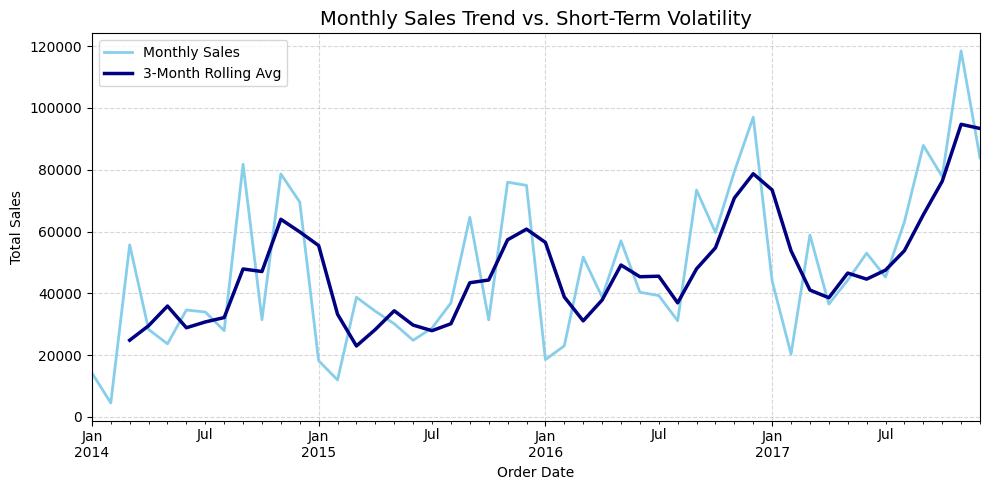

In [109]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df = df.set_index("Order Date")
monthly_sales=df["Sales"].resample("M").sum()
rolling_sales=monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(label="Monthly Sales", color="skyblue", linewidth=2)
rolling_sales.plot(label="3-Month Rolling Avg", color="navy", linewidth=2.5)
plt.title("Monthly Sales Trend vs. Short-Term Volatility", fontsize=14)
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

The rolling scale smooths the over pattern and helps in determining the overall direction of the business every three months whereas the raw monthly tells us exactly what amount are we selling each month and it fluctuates really easily.

# Task: **07**

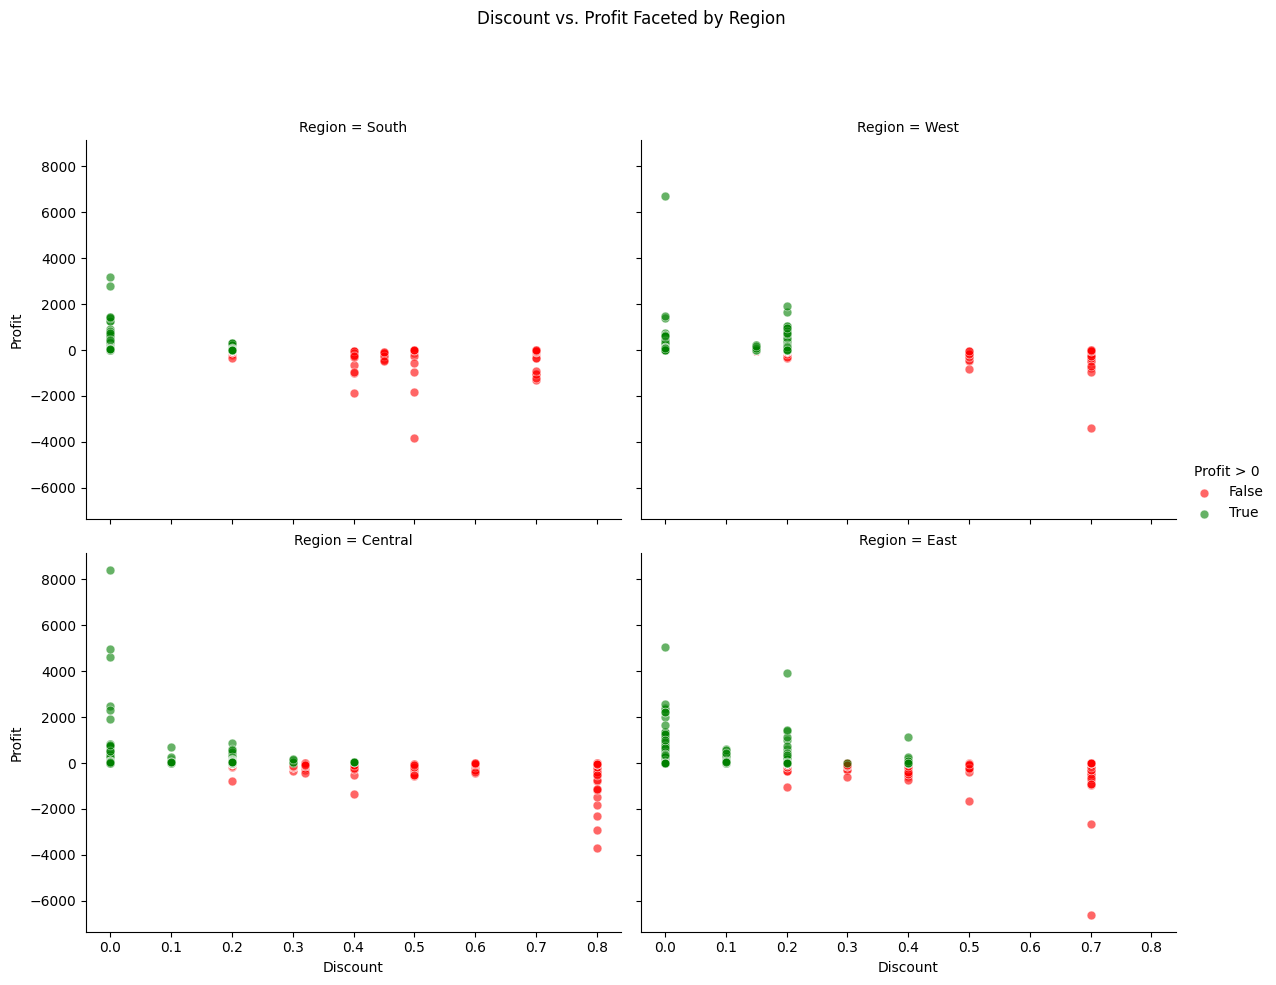

In [129]:
df["is_profit"] = df["Profit"] > 0
g = sns.FacetGrid(df,col="Region",hue="is_profit",palette={True: "green", False: "red"},height=5,aspect=1.2,col_wrap=2)
g.map(sns.scatterplot, "Discount", "Profit", alpha=0.6,s=40)
g.add_legend(title="Profit > 0")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Discount vs. Profit Faceted by Region")
plt.show()

Central is the only region where the discount went upto 80% as compared to all other regions.

# Task: **08**

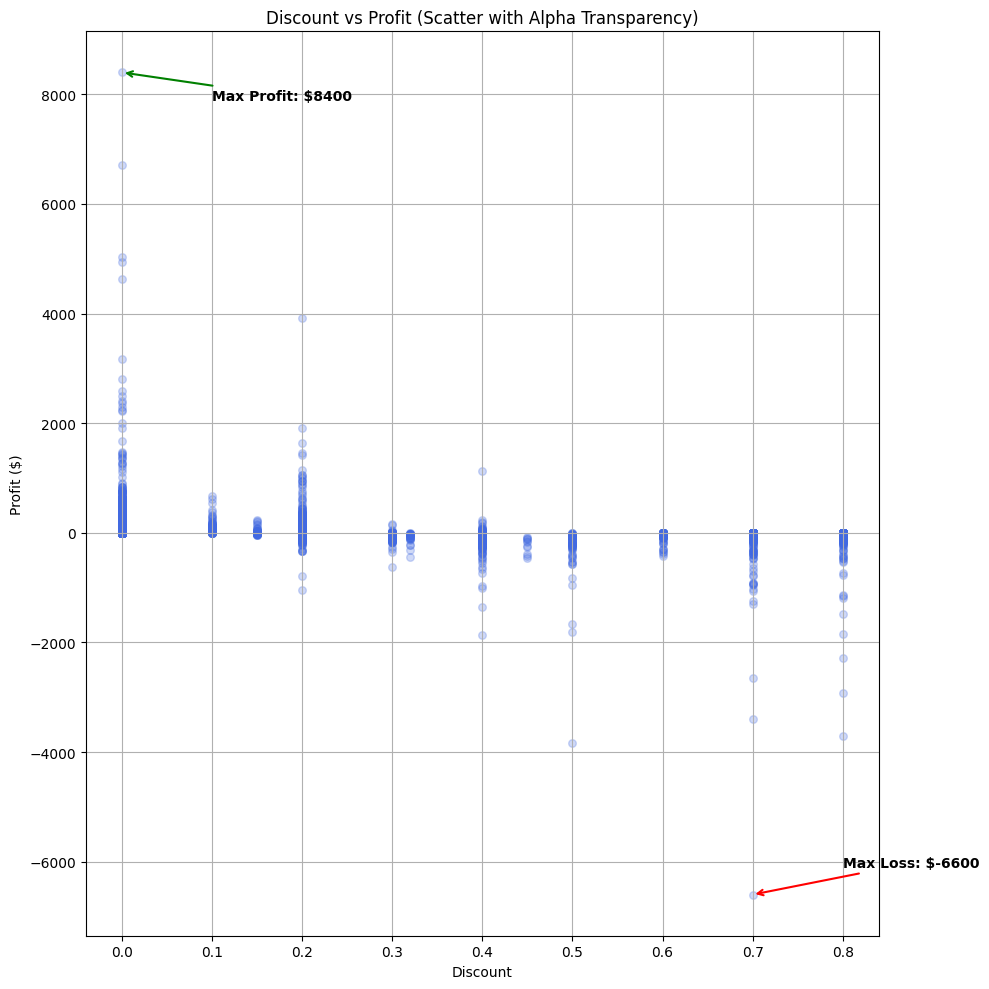

In [133]:
max_profit_row = df.loc[df["Profit"].idxmax()]
max_loss_row = df.loc[df["Profit"].idxmin()]

plt.figure(figsize=(10,10))
plt.scatter(df["Discount"],df["Profit"],alpha=0.25,color="royalblue",s=30,)
plt.annotate(
    f"Max Profit: ${float(max_profit_row['Profit']):.0f}",
    xy=(max_profit_row["Discount"], max_profit_row["Profit"]),
    xytext=(max_profit_row["Discount"] + 0.1, max_profit_row["Profit"] - 500),
    arrowprops=dict(arrowstyle="->", color="green", lw=1.5),
    fontsize=10,
    fontweight="bold",
)
plt.annotate(
    f"Max Loss: ${float(max_loss_row['Profit']):.0f}",
    xy=(max_loss_row["Discount"], max_loss_row["Profit"]),
    xytext=(max_loss_row["Discount"] + 0.1, max_loss_row["Profit"] + 500),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=10,
    fontweight="bold",
)
plt.title("Discount vs Profit (Scatter with Alpha Transparency)", fontsize=12)
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.grid(True)
plt.tight_layout()
plt.show()